# Sequence to Sequence Model.
___
In this Notebook we will try to build and understand a Seq to Seq Model for Machine Translations.

# Download the dataset:

The following script will download the dataset and stores the file in designated folder.

Please change the folder path as per your file structure.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import os
import re
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
DATA_PATH = "/content/drive/MyDrive/AI and Machine Learning/cleaned_data.csv"

cleaned_data = pd.read_csv(DATA_PATH)

# Drop rows with any missing values
cleaned_data.dropna(inplace=True)
cleaned_data.reset_index(drop=True, inplace=True)

print(f"Dataset shape : {cleaned_data.shape}")
print(f"Columns       : {cleaned_data.columns.tolist()}")
cleaned_data.sample(6)

Dataset shape : (2689, 2)
Columns       : ['cleaned_source', 'cleaned_target']


,cleaned_source,cleaned_target
2356,tom couldnt read until he was thirteen.,START_ टमले तेह्र वर्षको नहुँदासम्म पढ्न सकेनन...
2265,tom is a very talented young director.,START_ टम धेरै प्रतिभाशाली युवा निर्देशक हुन्।...
2429,tom gave his father a tie on fathers day.,START_ टमले आफ्नो बुबालाई बुबा को मुख हेर्ने द...
2359,"tom is a billionaire, not a millionaire.","START_ टम अर्बपति हो, करोडपति होइन। _END"
142,we have room.,START_ हामीसँग कोठा छ। _END
1979,itll be finished in a day or two.,START_ यो एक दुई दिनमा सकिन्छ। _END


In [4]:
# --- Source (English) vocabulary ---
all_source_words = set()
for sentence in cleaned_data['cleaned_source']:
    for word in str(sentence).split():
        all_source_words.add(word)

# --- Target (Nepali) vocabulary ---
all_target_words = set()
for sentence in cleaned_data['cleaned_target']:
    for word in str(sentence).split():
        all_target_words.add(word)

source_words = sorted(list(all_source_words))
target_words = sorted(list(all_target_words))

print(f"Source vocabulary size : {len(source_words)}")
print(f"Target vocabulary size : {len(target_words)}")

Source vocabulary size : 2681
Target vocabulary size : 3269


In [5]:
source_length_list = [len(str(s).split()) for s in cleaned_data['cleaned_source']]
target_length_list = [len(str(s).split()) for s in cleaned_data['cleaned_target']]

max_source_length = max(source_length_list)
max_target_length = max(target_length_list)

print(f"Max source sentence length : {max_source_length}")
print(f"Max target sentence length : {max_target_length}")

Max source sentence length : 25
Max target sentence length : 22


In [6]:
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

# Word → index
source_word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
source_word2idx.update({word: i + 2 for i, word in enumerate(source_words)})

target_word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
target_word2idx.update({word: i + 2 for i, word in enumerate(target_words)})

# Index → word
source_idx2word = {idx: word for word, idx in source_word2idx.items()}
target_idx2word = {idx: word for word, idx in target_word2idx.items()}

print(f"Source vocab (with special tokens) : {len(source_word2idx)}")
print(f"Target vocab (with special tokens) : {len(target_word2idx)}")

Source vocab (with special tokens) : 2683
Target vocab (with special tokens) : 3271


In [7]:
cleaned_data = shuffle(cleaned_data, random_state=42)
cleaned_data.reset_index(drop=True, inplace=True)

X = cleaned_data['cleaned_source']
y = cleaned_data['cleaned_target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 2420
Testing  samples : 269


In [8]:
# Vocabulary sizes (include PAD and UNK)
num_encoder_tokens = len(source_word2idx)   # source vocab size
num_decoder_tokens = len(target_word2idx)   # target vocab size

latent_dim  = 256    # LSTM hidden units
batch_size  = 128
epochs      = 50     # EarlyStopping will stop sooner if needed

print(f"num_encoder_tokens : {num_encoder_tokens}")
print(f"num_decoder_tokens : {num_decoder_tokens}")
print(f"latent_dim         : {latent_dim}")
print(f"batch_size         : {batch_size}")
print(f"epochs             : {epochs}")

num_encoder_tokens : 2683
num_decoder_tokens : 3271
latent_dim         : 256
batch_size         : 128
epochs             : 50


In [9]:
def generate_batch(X, y, batch_size=128):
    """Infinite generator that yields (inputs, targets) batches."""
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    while True:
        for j in range(0, len(X), batch_size):
            batch_X = X[j: j + batch_size]
            batch_y = y[j: j + batch_size]

            encoder_input_data  = np.zeros((len(batch_X), max_source_length), dtype='float32')
            decoder_input_data  = np.zeros((len(batch_X), max_target_length), dtype='float32')
            decoder_target_data = np.zeros(
                (len(batch_X), max_target_length, num_decoder_tokens), dtype='float32'
            )

            for i, (src, tgt) in enumerate(zip(batch_X, batch_y)):
                src_seq = [
                    source_word2idx.get(w, source_word2idx[UNK_TOKEN])
                    for w in str(src).split()
                ]
                tgt_seq = [
                    target_word2idx.get(w, target_word2idx[UNK_TOKEN])
                    for w in str(tgt).split()
                ]

                encoder_input_data[i]  = pad_sequences(
                    [src_seq], maxlen=max_source_length, padding='post'
                )[0]
                decoder_input_data[i]  = pad_sequences(
                    [tgt_seq], maxlen=max_target_length, padding='post'
                )[0]

                # decoder_target is decoder_input shifted one step forward
                for t in range(1, len(tgt_seq)):
                    decoder_target_data[i, t - 1, tgt_seq[t]] = 1.0

            yield (
                (encoder_input_data, decoder_input_data),
                decoder_target_data
            )


# ---- Wrap generators as tf.data.Dataset for performance ----
def create_tf_dataset(X, y, batch_size=128):
    output_signature = (
        (
            tf.TensorSpec(shape=(None, max_source_length), dtype=tf.float32),
            tf.TensorSpec(shape=(None, max_target_length), dtype=tf.float32),
        ),
        tf.TensorSpec(shape=(None, max_target_length, num_decoder_tokens), dtype=tf.float32),
    )
    return tf.data.Dataset.from_generator(
        lambda: generate_batch(X, y, batch_size),
        output_signature=output_signature,
    )


train_dataset = create_tf_dataset(X_train, y_train, batch_size=batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset   = create_tf_dataset(X_test,  y_test,  batch_size=batch_size).prefetch(tf.data.AUTOTUNE)

# Quick sanity check on the first batch
for batch in train_dataset.take(1):
    (enc_in, dec_in), dec_tgt = batch
    print(f"encoder_input  shape : {enc_in.shape}")
    print(f"decoder_input  shape : {dec_in.shape}")
    print(f"decoder_target shape : {dec_tgt.shape}")

encoder_input  shape : (128, 25)
decoder_input  shape : (128, 22)
decoder_target shape : (128, 22, 3271)


In [14]:
def define_encoder(input_shape, num_encoder_tokens, latent_dim):
    """
    Encoder for Seq2Seq model.

    Parameters
    ----------
    input_shape        : tuple — shape of each input sequence, e.g. (max_source_length,)
    num_encoder_tokens : int   — source vocabulary size
    latent_dim         : int   — embedding & LSTM dimensionality

    Returns
    -------
    encoder_inputs  : keras.Input layer
    encoder_states  : list of [hidden_state, cell_state] tensors
    """
    encoder_inputs = Input(shape=input_shape, name='encoder_inputs')

    enc_emb = Embedding(
        num_encoder_tokens, latent_dim,
        mask_zero=True, name='encoder_embedding'
    )(encoder_inputs)

    encoder_lstm = LSTM(latent_dim, return_state=True, name='encoder_lstm')
    _, state_h, state_c = encoder_lstm(enc_emb)
    encoder_states = [state_h, state_c]

    return encoder_inputs, encoder_states

In [17]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

def define_encoder(input_shape, num_encoder_tokens, latent_dim):
    encoder_inputs = Input(shape=input_shape, name='encoder_inputs')
    enc_emb = Embedding(num_encoder_tokens, latent_dim, mask_zero=True, name='encoder_embedding')(encoder_inputs)
    encoder_lstm = LSTM(latent_dim, return_state=True, name='encoder_lstm')
    _, state_h, state_c = encoder_lstm(enc_emb)
    encoder_states = [state_h, state_c]
    return encoder_inputs, encoder_states

def define_decoder(latent_dim, num_decoder_tokens, encoder_states, max_target_length):
    decoder_inputs = Input(shape=(None,), name='decoder_inputs')
    dec_emb_layer = Embedding(num_decoder_tokens, latent_dim, mask_zero=True, name='decoder_embedding')
    dec_emb = dec_emb_layer(decoder_inputs)
    decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, name='decoder_lstm')
    decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
    decoder_dense = Dense(num_decoder_tokens, activation='softmax', name='decoder_dense')
    decoder_outputs = decoder_dense(decoder_outputs)
    return decoder_inputs, decoder_outputs, dec_emb_layer, decoder_lstm, decoder_dense

def build_seq2seq_model(input_shape, num_encoder_tokens, num_decoder_tokens, latent_dim, max_target_length):
    encoder_inputs, encoder_states = define_encoder(input_shape, num_encoder_tokens, latent_dim)
    decoder_inputs, decoder_outputs, dec_emb_layer, decoder_lstm, decoder_dense = (
        define_decoder(latent_dim, num_decoder_tokens, encoder_states, max_target_length)
    )
    model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
    return model, encoder_inputs, decoder_inputs, encoder_states, dec_emb_layer, decoder_lstm, decoder_dense

(model, encoder_inputs, decoder_inputs, encoder_states,
 dec_emb_layer, decoder_lstm, decoder_dense) = build_seq2seq_model(
    input_shape        = (max_source_length,),
    num_encoder_tokens = num_encoder_tokens,
    num_decoder_tokens = num_decoder_tokens,
    latent_dim         = latent_dim,
    max_target_length  = max_target_length
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 25, 256)   │    686,848 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 25)        │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, None, 256) │    837,376 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    525,312 │ encoder_embeddin… │
│                     │ (None, 256),      │            │ not_equal_2[0][0] │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │    525,312 │ decoder_embeddin… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None,      │    840,647 │ decoder_lstm[0][… │
│ (Dense)             │ 3271)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,415,495 (13.03 MB)

 Trainable params: 3,415,495 (13.03 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# ---- Compile ----
model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ---- Callbacks ----
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_seq2seq_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ---- Steps per epoch ----
train_samples       = len(X_train)
val_samples         = len(X_test)
steps_per_epoch     = max(1, train_samples // batch_size)
validation_steps    = max(1, val_samples   // batch_size)

# ---- Train ----
history = model.fit(
    train_dataset,
    steps_per_epoch  = steps_per_epoch,
    epochs           = epochs,
    validation_data  = val_dataset,
    validation_steps = validation_steps,
    callbacks        = callbacks
)

# Save final model
model.save('final_seq2seq_model.h5')
print(' Training complete!')

Epoch 1/50
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1093 - loss: 6.9669
Epoch 1: val_accuracy improved from None to 0.13936, saving model to best_seq2seq_model.h5



Epoch 1: finished saving model to best_seq2seq_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.1295 - loss: 6.9084 - val_accuracy: 0.1394 - val_loss: 6.3743
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1370 - loss: 5.9433
Epoch 2: val_accuracy did not improve from 0.13936
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.1375 - loss: 5.6920 - val_accuracy: 0.1394 - val_loss: 5.4325
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1396 - loss: 5.3375
Epoch 3: val_accuracy improved from 0.13936 to 0.16658, saving model to best_seq2seq_model.h5



Epoch 3: finished saving model to best_seq2seq_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.1478 - loss: 5.2559 - val_accuracy: 0.1666 - val_loss: 5.2380
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1635 - loss: 5.0805
Epoch 4: val_accuracy improved from 0.16658 to 0.16712, saving model to best_seq2seq_model.h5



Epoch 4: finished saving model to best_seq2seq_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.1620 - loss: 5.0520 - val_accuracy: 0.1671 - val_loss: 5.1308
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.1653 - loss: 4.9678
Epoch 5: val_accuracy improved from 0.16712 to 0.16766, saving model to best_seq2seq_model.h5



Epoch 5: finished saving model to best_seq2seq_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.1632 - loss: 4.9501 - val_accuracy: 0.1677 - val_loss: 5.0858
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1635 - loss: 4.8898
Epoch 6: val_accuracy did not improve from 0.16766
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.1633 - loss: 4.8874 - val_accuracy: 0.1666 - val_loss: 5.0627
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.1646 - loss: 4.8260
Epoch 7: val_accuracy improved from 0.16766 to 0.17039, saving model to best_seq2seq_model.h5


...


Epoch 39: finished saving model to best_seq2seq_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.2015 - loss: 4.0652 - val_accuracy: 0.1971 - val_loss: 4.6821
Epoch 40/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2013 - loss: 4.0657
Epoch 40: val_accuracy did not improve from 0.19706
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.2037 - loss: 4.0345 - val_accuracy: 0.1965 - val_loss: 4.6870
Epoch 41/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.2030 - loss: 4.0599
Epoch 41: val_accuracy did not improve from 0.19706
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.2058 - loss: 4.0246 - val_accuracy: 0.1971 - val_loss: 4.6627
Epoch 42/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.2127 - loss: 3.9781
Epoch 42: val_accuracy did not improve from 0.19706
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.2104 - loss: 3.9852 - val_accuracy: 0.1960 - val_loss: 4.6631
Epoch 43/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 


Epoch 44: finished saving model to best_seq2seq_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 0.2136 - loss: 3.9338 - val_accuracy: 0.1976 - val_loss: 4.6594
Epoch 45/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.2209 - loss: 3.9007
Epoch 45: val_accuracy improved from 0.19760 to 0.20523, saving model to best_seq2seq_model.h5



Epoch 45: finished saving model to best_seq2seq_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.2171 - loss: 3.9061 - val_accuracy: 0.2052 - val_loss: 4.6251
Epoch 46/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.2195 - loss: 3.8680
Epoch 46: val_accuracy did not improve from 0.20523
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.2195 - loss: 3.8702 - val_accuracy: 0.1998 - val_loss: 4.6322
Epoch 47/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.2154 - loss: 3.8729
Epoch 47: val_accuracy improved from 0.20523 to 0.20686, saving model to best_seq2seq_model.h5



Epoch 47: finished saving model to best_seq2seq_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.2192 - loss: 3.8520 - val_accuracy: 0.2069 - val_loss: 4.6007
Epoch 48/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2201 - loss: 3.8402
Epoch 48: val_accuracy did not improve from 0.20686
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.2223 - loss: 3.8167 - val_accuracy: 0.2036 - val_loss: 4.6051
Epoch 49/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2218 - loss: 3.8384
Epoch 49: val_accuracy did not improve from 0.20686
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.2243 - loss: 3.8035 - val_accuracy: 0.2036 - val_loss: 4.6026
Epoch 50/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2247 - loss: 3.7852
Epoch 50: val_accuracy did not improve from 0.20686
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.2268 - loss: 3.7711 - val_accuracy: 0.2052 - val_loss: 4.5925
Restoring model weights from the end of the best epoch: 50.


 Training complete!


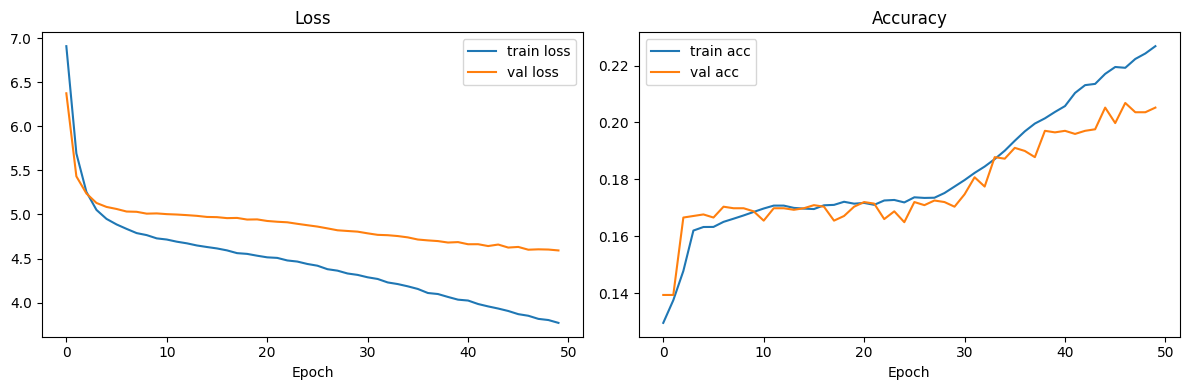

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='train loss')
axes[0].plot(history.history['val_loss'], label='val loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='train acc')
axes[1].plot(history.history['val_accuracy'], label='val acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
# ---- Inference Encoder ----
encoder_model = Model(encoder_inputs, encoder_states, name='encoder_inference')

# ---- Inference Decoder ----
decoder_state_input_h  = Input(shape=(latent_dim,), name='decoder_state_input_h')
decoder_state_input_c  = Input(shape=(latent_dim,), name='decoder_state_input_c')
decoder_states_inputs  = [decoder_state_input_h, decoder_state_input_c]

# Reuse the shared embedding layer
dec_emb_inf = dec_emb_layer(decoder_inputs)

# Reuse the shared LSTM, passing previous states
decoder_outputs_inf, state_h_inf, state_c_inf = decoder_lstm(
    dec_emb_inf, initial_state=decoder_states_inputs
)
decoder_states_inf = [state_h_inf, state_c_inf]

# Reuse the shared dense layer
decoder_outputs_inf = decoder_dense(decoder_outputs_inf)

decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs_inf] + decoder_states_inf,
    name='decoder_inference'
)

print('Inference models built.')

Inference models built.


In [21]:
def decode_sequence(input_seq, max_decode_len=50):
    """
    Greedily decode a source sequence to a target string.

    Parameters
    ----------
    input_seq     : np.ndarray of shape (1, max_source_length)
    max_decode_len: int — safety limit on output length

    Returns
    -------
    str — decoded sentence (without START_ / _END tokens)
    """
    # 1. Encode source
    states_value = encoder_model.predict(input_seq, verbose=0)

    # 2. Seed decoder with START_ token
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = target_word2idx.get('START_', 1)

    decoded_sentence = ''
    stop_condition   = False

    while not stop_condition:
        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states_value, verbose=0
        )

        # 3. Sample the most probable token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word        = target_idx2word.get(sampled_token_index, UNK_TOKEN)

        decoded_sentence += ' ' + sampled_word

        # 4. Check stop condition
        if sampled_word == '_END' or len(decoded_sentence.split()) > max_decode_len:
            stop_condition = True

        # 5. Update decoder input and states
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index
        states_value = [h, c]

    # Remove START_ and _END tokens from output
    tokens = decoded_sentence.strip().split()
    tokens = [t for t in tokens if t not in ('START_', '_END')]
    return ' '.join(tokens)

In [22]:
X_train_r = X_train.reset_index(drop=True)
y_train_r = y_train.reset_index(drop=True)

train_gen = generate_batch(X_train_r, y_train_r, batch_size=1)

print(f"{'INPUT (English)':<35} {'ACTUAL (Nepali)':<35} {'PREDICTED (Nepali)'}")
print('-' * 100)

for k in range(10):
    (input_seq, _), _ = next(train_gen)

    decoded = decode_sequence(input_seq)
    actual  = y_train_r[k].replace('START_', '').replace('_END', '').strip()

    print(f"{X_train_r[k]:<35} {actual:<35} {decoded}")

INPUT (English)                     ACTUAL (Nepali)                     PREDICTED (Nepali)
----------------------------------------------------------------------------------------------------
phoenix is the capital of arizona.  फिनिक्स एरिजोना को राजधानी हो।      उनी ढोका राजधानी हो।
he is the greatest singer that ever lived. उनी अहिलेसम्मकै उत्कृष्ट गायक हुन्। उनी मौसम धेरै कस्तो हो।
my parents died when i was thirteen. म वर्षको हुँदा आमाबुवाको मृत्यु भयो। म लाग्छ कि म धेरै गर्न चाहन्छु।
i didnt want to go, but i did.      मलाई जान मन थिएन, तर म गएँ।         म लाग्छ म धेरै चाहन्न।
he is foolish.                      ऊ मूर्ख छ।                          उनी गरौँ छ।
i cant beat tom.                    म टमलाई हराउन सक्दिन।               म तिम्रो मन चाहन्न।
i really dont like dogs.            मलाई साँच्चै कुकुरहरू मन पर्दैन।    म तिम्रो धेरै चाहन्न।
are you out of work?                के तपाईसंग काम छैन ?                के के के टम हुनुहुन्छ?
tom probably went to his friends house. टम साय

In [23]:
def translate(sentence):
    """Translate a raw English sentence to Nepali."""
    # Tokenise and encode
    words   = str(sentence).lower().split()
    seq     = [source_word2idx.get(w, source_word2idx[UNK_TOKEN]) for w in words]
    padded  = pad_sequences([seq], maxlen=max_source_length, padding='post')
    result  = decode_sequence(padded)
    print(f"English  : {sentence}")
    print(f"Nepali   : {result}")
    print()


translate("i am here.")
translate("who are you?")
translate("i love you.")
translate("how are you?")
translate("thank you.")

English  : i am here.
Nepali   : म पागल छु।

English  : who are you?
Nepali   : के के के

English  : i love you.
Nepali   : म पागल छु।

English  : how are you?
Nepali   : के के के

English  : thank you.
Nepali   : उनी गरौँ

